# New SuStain model training

In [10]:
# pip install git+https://github.com/ucl-pond/pySuStaIn

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import pandas as pd
import pySuStaIn
import warnings
warnings.filterwarnings('ignore')

In [2]:
final_df=pd.read_csv('/Users/gracieshao/Desktop/ALS T1s/data/preprocessed/final_cleaned_zscored_features_COMBINED.csv')

In [3]:
# ── Top 10 feature column names ───────────────────────────────────────────────
top10 = pd.read_csv(
    '/Users/gracieshao/Desktop/ALS T1s/Scripts/top10_ttest_uncorrelated_roi_features_combined.csv')
top10_cols = (top10['roi'] + '__' + top10['feature']).tolist()

# ── Parse metadata from INFO_PatientName ──────────────────────────────────────
parts = final_df['INFO_PatientName'].str.split('_')
final_df['SubjectID'] = parts.str[2]
final_df['Visit']     = parts.str.get(4)
final_df['Group']     = final_df['SubjectID'].str[0].map({'P': 'Patient', 'C': 'Control'})

# ── V1 wide matrix — ALL subjects (patients + controls) ───────────────────────
# final_df should already have Visit and Group columns parsed
v1_all = final_df[final_df['Visit'] == 'V1'].copy()

FEAT_COLS_ALL = [c for c in v1_all.columns
                 if c not in ['INFO_PatientName', 'INFO_NameOfRoi',
                               'SubjectID', 'Visit', 'Group']]

wide_all = v1_all.pivot_table(
    index   = 'INFO_PatientName',
    columns = 'INFO_NameOfRoi',
    values  = FEAT_COLS_ALL,
    aggfunc = 'first'
)
wide_all.columns = [f"{roi}__{feat}" for feat, roi in wide_all.columns]
wide_all = wide_all.reset_index()
wide_all['Group'] = wide_all['INFO_PatientName'].str.split('_').str[2].str[0].map(
    {'P': 'Patient', 'C': 'Control'})

# ── Controls first, then patients ─────────────────────────────────────────────
wide_all = pd.concat([
    wide_all[wide_all['Group'] == 'Control'],
    wide_all[wide_all['Group'] == 'Patient']
]).reset_index(drop=True)

M_control = (wide_all['Group'] == 'Control').sum()
M         = len(wide_all)
N         = len(top10_cols)
print(f"Total subjects: {M}  |  Controls: {M_control}  |  Patients: {M - M_control}")
print(f"Biomarkers: {N}")

# ── Raw data matrix ───────────────────────────────────────────────────────────
X_data = wide_all[top10_cols].values.copy()
print(f"Data matrix shape: {X_data.shape}")
print(f"NaNs: {np.isnan(X_data).sum()}")

# ── Directionality fix ────────────────────────────────────────────────────────
# SuStaIn expects POSITIVE z-scores = abnormal
# Flip features where patients have LOWER values than controls (cohens_d < 0)
print("\nDirectionality check (flipping features where cohens_d < 0):")
for i, col in enumerate(top10_cols):
    roi, feat = col.split('__', 1)
    match = top10[(top10['roi'] == roi) & (top10['feature'] == feat)]
    if len(match) > 0:
        d = match['cohens_d'].values[0]
        if d < 0:
            X_data[:, i] = -X_data[:, i]
            print(f"  Flipped #{i+1}: {col[:60]}  (d={d:.3f})")
        else:
            print(f"  Kept    #{i+1}: {col[:60]}  (d={d:.3f})")

# ── SuStaIn parameters ────────────────────────────────────────────────────────
Z_vals = np.array([[1]] * N)                                # single z=1 threshold
Z_max  = np.percentile(np.abs(X_data), 95, axis=0)         # 95th percentile per biomarker

SuStaInLabels = []
for _, row in top10.iterrows():
    roi_short  = next((p for p in row['roi'].split('_') if p.startswith('#')), row['roi'][-4:])
    roi_region = row['roi'].split('_label')[0].split('-')[-1]
    feat_short = row['feature'][:30]
    SuStaInLabels.append(f"{roi_region} {roi_short}\n{feat_short}")

print(f"\nZ_vals shape:  {Z_vals.shape}")
print(f"Z_max:         {np.round(Z_max, 3)}")
print(f"\nBiomarker labels:")
for i, lbl in enumerate(SuStaInLabels):
    print(f"  #{i+1}: {lbl.replace(chr(10), ' | ')}")

# ── Save DataAll.csv for SuStaIn ──────────────────────────────────────────────
sustain_df = pd.DataFrame(X_data, columns=top10_cols)
sustain_df.insert(0, 'SubjectID',   wide_all['INFO_PatientName'].values)
sustain_df.insert(1, 'Group',       wide_all['Group'].values)
sustain_df.to_csv(
    '/Users/gracieshao/Desktop/ALS T1s/SuStain/DataAll.csv', index=False)
print(f"\nSaved: DataAll.csv  (controls={M_control}, patients={M-M_control})")

# ── Summary of SuStaIn inputs ─────────────────────────────────────────────────
print("\n=== SuStaIn input summary ===")
print(f"  data shape:    {X_data.shape}   ← pass as 'data'")
print(f"  N  = {N}                         ← number of biomarkers")
print(f"  M  = {M}                        ← total subjects")
print(f"  M_control = {M_control}               ← controls (first {M_control} rows)")
print(f"  N_S_max   = 3                    ← test up to 3 subtypes")
print(f"  Z_vals shape: {Z_vals.shape}")
print(f"  Z_max: {np.round(Z_max, 3)}")

Total subjects: 455  |  Controls: 204  |  Patients: 251
Biomarkers: 10
Data matrix shape: (455, 10)
NaNs: 0

Directionality check (flipping features where cohens_d < 0):
  Kept    #1: JHU-WhiteMatter-labels-1mm_#26__INTENSITY-BASED-RIM_RIM-Inte  (d=0.693)
  Kept    #2: harvardoxford-subcortical_label_all_#9__GLCM_DifferenceAvera  (d=0.629)
  Flipped #3: JHU-WhiteMatter-labels-1mm_#6__INTENSITY-BASED_MedianIntensi  (d=-0.619)
  Flipped #4: harvardoxford-cortical_label_all_#1__INTENSITY-HISTOGRAM_Int  (d=-0.515)
  Kept    #5: harvardoxford-cortical_label_all_#28__INTENSITY-BASED_Intens  (d=0.497)
  Kept    #6: JHU-WhiteMatter-labels-1mm_#4__INTENSITY-BASED-RIM_RIM-Inten  (d=0.461)
  Kept    #7: harvardoxford-cortical_label_all_#33__INTENSITY-BASED_Intens  (d=0.472)
  Kept    #8: JHU-WhiteMatter-labels-1mm_#6__GLSZM_LargeZoneEmphasis(IBSI:  (d=0.456)
  Flipped #9: harvardoxford-cortical_label_all_#42__INTENSITY-BASED_25thIn  (d=-0.465)
  Flipped #10: harvardoxford-subcortical_label_all_#5

# Data loading

In [ ]:
# ── Load DataAll.csv — controls first (rows 0..M_control-1), then patients ────
df        = pd.read_csv('/Users/gracieshao/Desktop/ALS T1s/SuStain/DataAll.csv')
data      = df.drop(columns=['SubjectID', 'Group']).values   # shape (455, 10)

N          = 10
M          = len(df)                                  # 455 total
M_control  = (df['Group'] == 'Control').sum()         # 204 controls
N_S_max    = 3
N_S_gt     = 3

print(f"Total: {M}  |  Controls: {M_control}  |  Patients: {M - M_control}")

Z_vals = np.array([[1]] * N)
Z_max  = np.percentile(np.abs(data), 95, axis=0)

In [5]:
# Input the settings for z-score SuStaIn
# To make the tutorial run faster I've set 
# N_startpoints = 10 and N_iterations_MCMC = int(1e4)
# I recommend using N_startpoints = 25 and 
# N_iterations_MCMC = int(1e5) or int(1e6) in general though
N_startpoints = 25
N_S_max = N_S_gt+1
N_iterations_MCMC = int(1e5)
output_folder = os.path.join(os.getcwd(), 'sim')
dataset_name = 'sim'
sustain_input = pySuStaIn.ZscoreSustain(data,
                              Z_vals,
                              Z_max,
                              SuStaInLabels,
                              N_startpoints,
                              N_S_max, 
                              N_iterations_MCMC, 
                              output_folder, 
                              dataset_name, 
                              False)

if os.path.exists(output_folder):
    shutil.rmtree(output_folder)
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

In [6]:
# runs the sustain algorithm with the inputs set in sustain_input above
samples_sequence,   \
samples_f,          \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage  = sustain_input.run_sustain_algorithm()

Failed to find pickle file: /Users/gracieshao/Desktop/ALS T1s/Scripts/sim/pickle_files/sim_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem
Overall ML likelihood is -3574.936505795081


MCMC Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

MCMC Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

MCMC Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

MCMC Iteration:   0%|          | 0/100000 [00:00<?, ?it/s]

...

Failed to find pickle file: /Users/gracieshao/Desktop/ALS T1s/Scripts/sim/pickle_files/sim_subtype3.pickle. Running SuStaIn model for 3 subtype.
Splitting cluster 1 of 3
 + Resolving 2 cluster problem
 + Finding ML solution from hierarchical initialisation
- ML likelihood is [-3560.33923458]
Splitting cluster 2 of 3
 + Resolving 2 cluster problem
 + Finding ML solution from hierarchical initialisation
- ML likelihood is [-3560.33036158]
Splitting cluster 3 of 3
 + Resolving 2 cluster problem
 + Finding ML solution from hierarchical initialisation
- ML likelihood is [-3560.33696452]
Overall ML likelihood is [-3560.33036158]


MCMC Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

MCMC Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

MCMC Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

MCMC Iteration:   0%|          | 0/100000 [00:00<?, ?it/s]

# Visualization

<Figure size 1400x600 with 0 Axes>

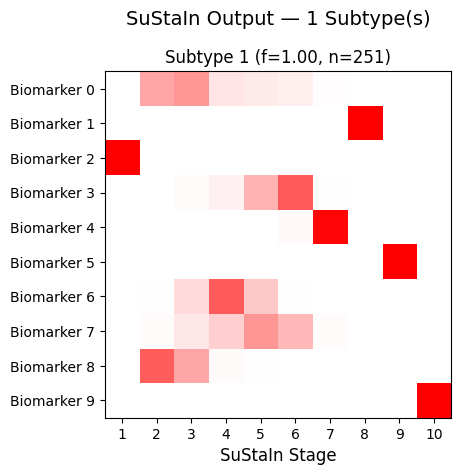

<Figure size 1400x600 with 0 Axes>

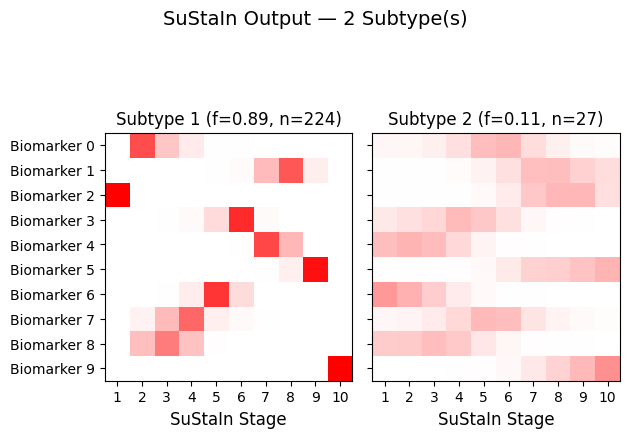

<Figure size 1400x600 with 0 Axes>

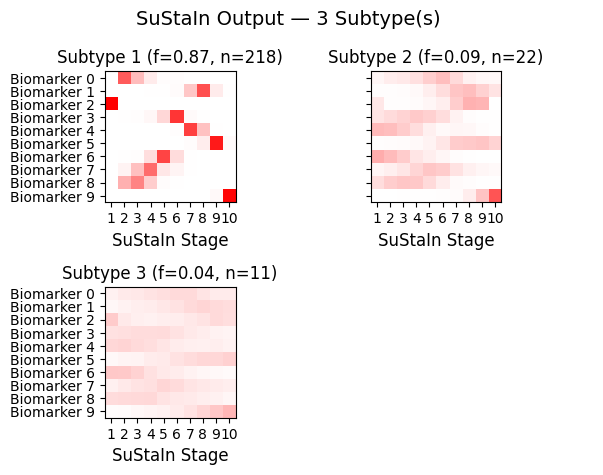

<Figure size 1400x600 with 0 Axes>

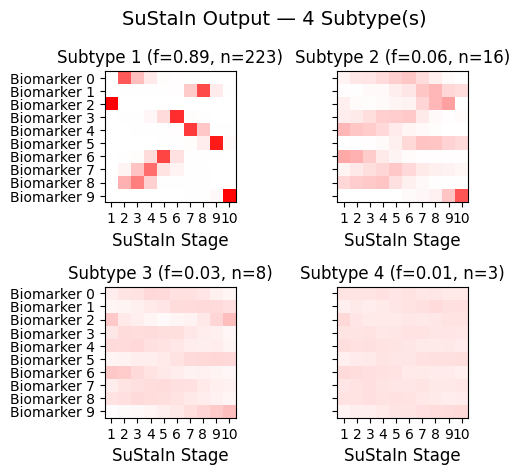

In [7]:
# ── Plot positional variance diagrams for all subtype models ──────────────────
for s in range(N_S_max):
    pickle_filename_s = os.path.join(output_folder, 'pickle_files',
                                     f'{dataset_name}_subtype{s}.pickle')
    if not os.path.exists(pickle_filename_s):
        print(f"Pickle not found for {s+1} subtype(s), skipping.")
        continue

    with open(pickle_filename_s, 'rb') as f:
        loaded_variables = pickle.load(f)

    samples_sequence = loaded_variables["samples_sequence"]
    samples_f        = loaded_variables["samples_f"]

    plt.figure(figsize=(14, 6))
    pySuStaIn.ZscoreSustain._plot_sustain_model(
        sustain_input, samples_sequence, samples_f, M)
    plt.suptitle(f'SuStaIn Output — {s+1} Subtype(s)', fontsize=14)
    plt.tight_layout()
    # plt.savefig(os.path.join(output_folder, f'SuStaIn_output_{s+1}_subtypes.png'),
    #             dpi=150, bbox_inches='tight')
    plt.show()

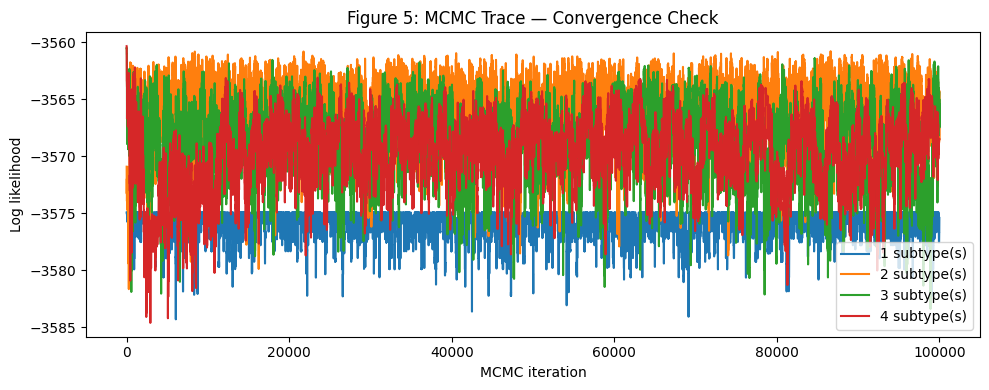

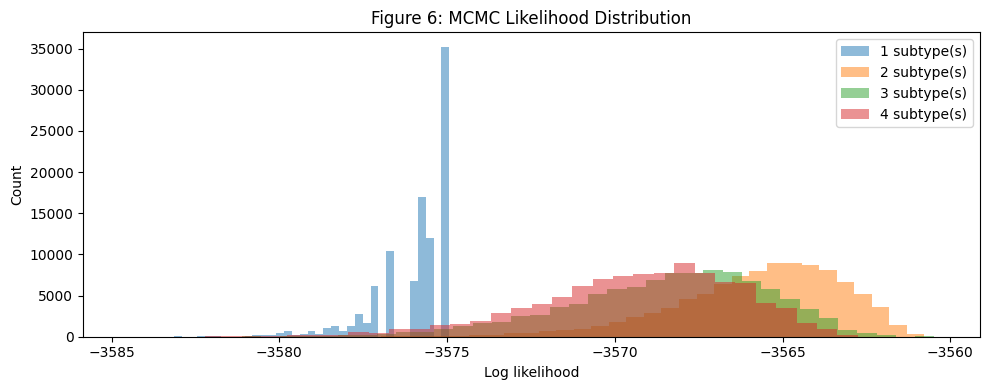

In [8]:
# ── MCMC convergence plots ────────────────────────────────────────────────────
fig0, ax0 = plt.subplots(figsize=(10, 4))
fig1, ax1 = plt.subplots(figsize=(10, 4))

for s in range(N_S_max):
    pickle_filename_s = os.path.join(output_folder, 'pickle_files',
                                     f'{dataset_name}_subtype{s}.pickle')
    if not os.path.exists(pickle_filename_s):
        continue
    with open(pickle_filename_s, 'rb') as f:
        samples_likelihood = pickle.load(f)["samples_likelihood"]

    ax0.plot(range(N_iterations_MCMC), samples_likelihood, label=f'{s+1} subtype(s)')
    ax1.hist(samples_likelihood, alpha=0.5, label=f'{s+1} subtype(s)', bins=40)

ax0.set(xlabel='MCMC iteration', ylabel='Log likelihood',
        title='Figure 5: MCMC Trace — Convergence Check')
ax0.legend()
fig0.tight_layout()
# fig0.savefig(os.path.join(output_folder, 'Figure_5_MCMC_trace.png'),
#              dpi=150, bbox_inches='tight')

ax1.set(xlabel='Log likelihood', ylabel='Count',
        title='Figure 6: MCMC Likelihood Distribution')
ax1.legend()
fig1.tight_layout()
# fig1.savefig(os.path.join(output_folder, 'Figure_6_MCMC_histogram.png'),
#              dpi=150, bbox_inches='tight')
plt.show()

# Cross-Validation (CVIC)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Cross-validation setup
# ══════════════════════════════════════════════════════════════════════════════
import sklearn.model_selection

# Label controls=0, patients=1 for stratified CV (keeps equal proportions per fold)
labels = np.ones(data.shape[0], dtype=int)
labels[:M_control] = 0   # first M_control rows are controls

N_folds = 10   # 10-fold CV recommended; lower (e.g. 3) for speed

cv     = sklearn.model_selection.StratifiedKFold(
            n_splits=N_folds, shuffle=True, random_state=42)
cv_it  = cv.split(data, labels)

# dtype=object avoids VisibleDeprecationWarning about ragged arrays
test_idxs = np.array([test for _, test in cv_it], dtype=object)

print(f"N_folds: {N_folds}")
print(f"Controls per fold (approx): {M_control // N_folds}")
print(f"Patients per fold (approx): {(M - M_control) // N_folds}")

# ── Run cross-validation ──────────────────────────────────────────────────────
# Retrains SuStaIn on each training fold, evaluates on the test fold.
# Pickle files are cached — re-running loads from disk instead of retraining.
CVIC, loglike_matrix = sustain_input.cross_validate_sustain_model(test_idxs)

print(f"\nCVIC per subtype model:                      {np.round(CVIC, 2)}")
print(f"Avg test log-likelihood per subtype model:   {np.round(np.mean(loglike_matrix, 0), 2)}")
optimal_N = int(np.argmin(CVIC)) + 1
print(f"\n→ Optimal number of subtypes (lowest CVIC): {optimal_N}")

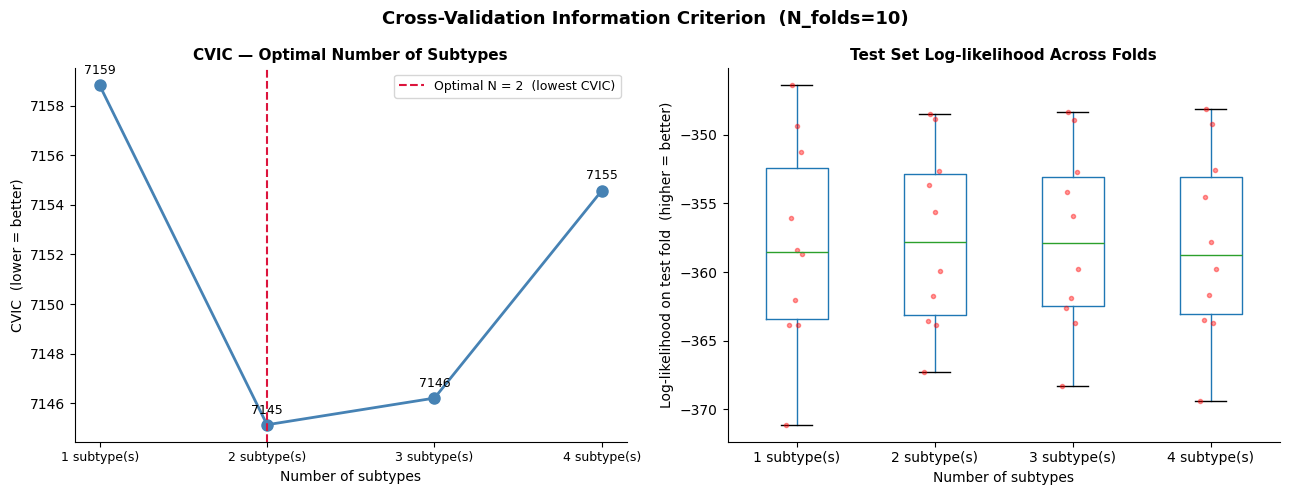

Decision rule (from pySuStaIn paper):
  → Choose the model with the LOWEST CVIC.
  → If a more-complex model improves CVIC by < 6, prefer the simpler model.

  CVIC(2 subtypes) - CVIC(1 subtypes) = -13.68
  CVIC(3 subtypes) - CVIC(2 subtypes) = +1.07 ← marginal (<6)
  CVIC(4 subtypes) - CVIC(3 subtypes) = +8.36


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CVIC + test log-likelihood plots
# ══════════════════════════════════════════════════════════════════════════════
import pylab

x_labels = [f'{i+1} subtype(s)' for i in range(N_S_max)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: CVIC ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(np.arange(1, N_S_max + 1), CVIC, 'o-',
        color='steelblue', linewidth=2, markersize=8)
ax.axvline(optimal_N, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Optimal N = {optimal_N}  (lowest CVIC)')
for i, v in enumerate(CVIC):
    ax.annotate(f'{v:.0f}', (i + 1, v),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_xticks(np.arange(1, N_S_max + 1))
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('CVIC  (lower = better)', fontsize=10)
ax.set_xlabel('Number of subtypes', fontsize=10)
ax.set_title('CVIC — Optimal Number of Subtypes', fontweight='bold', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Right: test set log-likelihood per fold ───────────────────────────────────
ax = axes[1]
df_loglike = pd.DataFrame(data=loglike_matrix, columns=x_labels)
df_loglike.boxplot(ax=ax, grid=False)
for i in range(N_S_max):
    y = df_loglike.iloc[:, i].values
    x = np.random.default_rng(42).normal(1 + i, 0.04, size=len(y))
    ax.plot(x, y, 'r.', alpha=0.4, markersize=6)
ax.set_ylabel('Log-likelihood on test fold  (higher = better)', fontsize=10)
ax.set_xlabel('Number of subtypes', fontsize=10)
ax.set_title('Test Set Log-likelihood Across Folds', fontweight='bold', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(f'Cross-Validation Information Criterion  (N_folds={N_folds})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('/Users/gracieshao/Desktop/ALS T1s/SuStain/CVIC_crossvalidation.png',
#             dpi=150, bbox_inches='tight')
plt.show()

# ── Decision rule ─────────────────────────────────────────────────────────────
print("Decision rule (from pySuStaIn paper):")
print("  → Choose the model with the LOWEST CVIC.")
print("  → If a more-complex model improves CVIC by < 6, prefer the simpler model.")
print()
for i in range(1, len(CVIC)):
    diff = CVIC[i] - CVIC[i - 1]
    mark = " ← marginal (<6)" if abs(diff) < 6 else ""
    print(f"  CVIC({i+1} subtypes) - CVIC({i} subtypes) = {diff:+.2f}{mark}")

# Sanity Check

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Extract SuStaIn subtype assignments for patients
# ══════════════════════════════════════════════════════════════════════════════
import pickle, os
import pandas as pd
import numpy as np

N_SUBTYPES = 2   # optimal number from CVIC

# Load N_SUBTYPES pickle (index = N_SUBTYPES - 1)
pickle_path = os.path.join(output_folder, 'pickle_files',
                            f'{dataset_name}_subtype{N_SUBTYPES-1}.pickle')
with open(pickle_path, 'rb') as f:
    loaded = pickle.load(f)

samples_sequence_s = loaded['samples_sequence']
samples_f_s        = loaded['samples_f']

# Access the internal sustainData object (name-mangled in AbstractSustain)
sustainData = sustain_input._AbstractSustain__sustainData

# Get ML subtype + stage for ALL 455 subjects (controls + patients)
ml_subtype_s, prob_ml_subtype_s, ml_stage_s, prob_ml_stage_s, \
    prob_subtype_s, prob_stage_s, prob_subtype_stage_s = \
    sustain_input.subtype_and_stage_individuals(
        sustainData, samples_sequence_s, samples_f_s, N_SUBTYPES
    )

print(f"Assigned {len(ml_subtype_s)} subjects total (controls + patients)")

# Patients are rows M_control onward — extract only those
patient_names    = df.iloc[M_control:]['SubjectID'].values
patient_subtypes = ml_subtype_s[M_control:].flatten()
patient_stages   = ml_stage_s[M_control:].flatten()

subtype_df = pd.DataFrame({
    'INFO_PatientName': patient_names,
    'Subtype':          [f'Subtype {int(s)+1}' for s in patient_subtypes],
    'Stage':            patient_stages.astype(int),
})

print(f"\nPatient subtype assignments: {len(subtype_df)}")
print(subtype_df['Subtype'].value_counts().sort_index())

# ── Build PSCID from INFO_PatientName ────────────────────────────────────────
CALSNIC1_SITE_MAP = {
    'CAL': 'Calgary', 'EDM': 'Edmonton', 'TOR': 'Toronto',
    'VAN': 'Vancouver', 'LHS': 'LHS', 'McGill': 'McGill',
    'MON': 'Montreal', 'QUE': 'Quebec', 'UTA': 'Utah', 'MIA': 'Miami'
}

def make_pscid(name):
    p = name.split('_')
    cohort, site, subj = p[0], p[1], p[2]
    if cohort == 'CALSNIC1':
        city = CALSNIC1_SITE_MAP.get(site, site)
        return f"{city} {subj}"
    else:
        return f"{site}{subj[1:]}"

subtype_df['PSCID'] = subtype_df['INFO_PatientName'].apply(make_pscid)

# Save
subtype_df.to_csv(
    '/Users/gracieshao/Desktop/ALS T1s/SuStain/sustain_subtype_assignments.csv',
    index=False)
print("\nSaved: sustain_subtype_assignments.csv")
print(subtype_df[['INFO_PatientName','PSCID','Subtype','Stage']].head(10).to_string(index=False))

# Longitudinal Check

PSCID resolved: 250 / 251
Matched for longitudinal: 235
V1:234  V2:164  V3:118
Chi-squared V1→V2: χ²=1.027, df=2, p=0.5985
Chi-squared V2→V3: χ²=1.199, df=2, p=0.5490


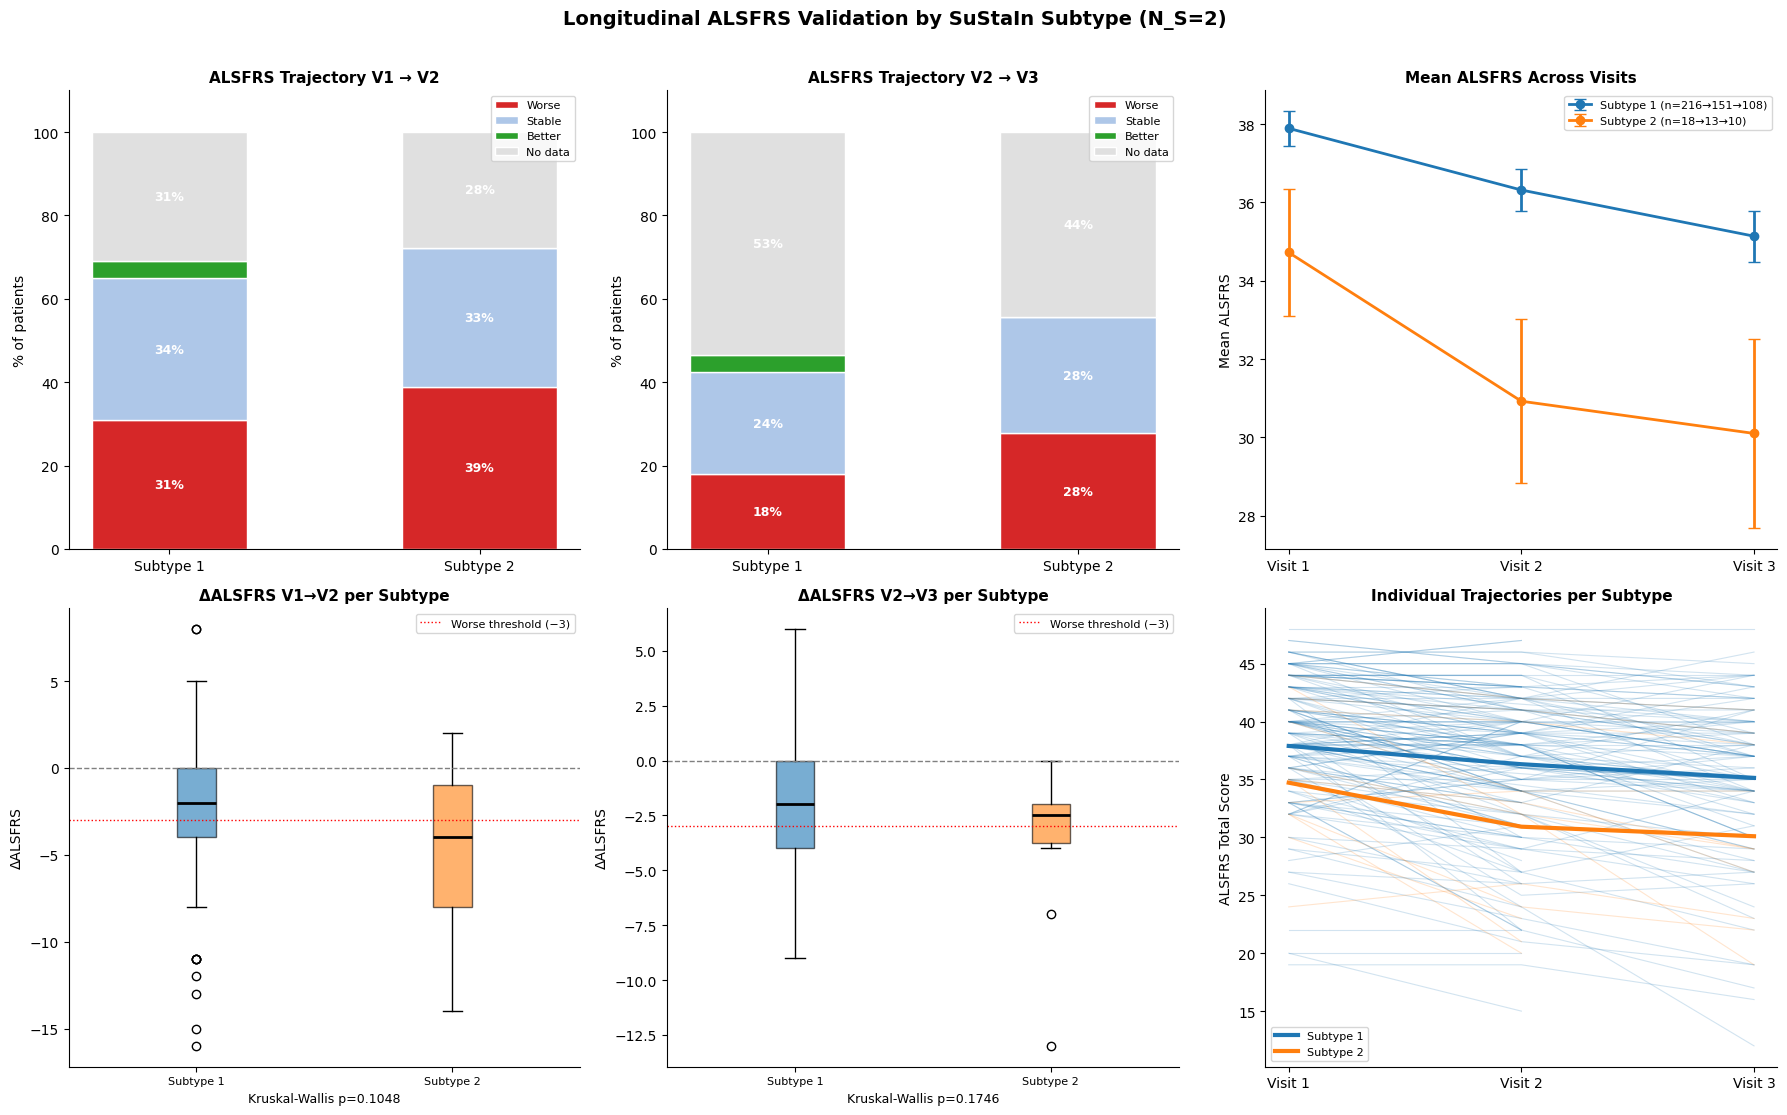


── Mean ΔALSFRS per subtype ──
           n_V1  mean_V1  n_V2  mean_V2  delta_V1V2_mean  delta_V1V2_std  n_V3  mean_V3  delta_V1V3_mean  delta_V1V3_std
Subtype                                                                                                                 
Subtype 1   216    37.89   151    36.32            -2.46            3.76   108    35.14            -4.31            5.09
Subtype 2    18    34.72    13    30.92            -5.00            5.13    10    30.10            -6.90            6.17


In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Longitudinal ALSFRS validation by SuStaIn subtype
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal
import warnings
warnings.filterwarnings('ignore')

SUBTYPE_ORDER  = [f'Subtype {i}' for i in range(1, N_SUBTYPES+1)]
SUBTYPE_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c'][:N_SUBTYPES]
THRESH = 3
METRIC = 'ALSFRS_TotalScore'
TRAJ_COLORS = {'Worse':'#d62728','Stable':'#aec7e8','Better':'#2ca02c','No data':'#e0e0e0'}
TRAJ_ORDER  = ['Worse','Stable','Better','No data']

# ── Load clinical sheet ───────────────────────────────────────────────────────
clin = pd.read_excel(
    '/Users/gracieshao/Desktop/ALS T1s/Final_Data_sheet_April2025.xlsx',
    sheet_name='Sheet_MRI')
clin['PSCID']       = clin['PSCID'].astype(str).str.strip()
clin['Visit Label'] = clin['Visit Label'].astype(str).str.strip()

clinical_ids = set(clin['PSCID'].unique())

# ── PSCID resolver ────────────────────────────────────────────────────────────
CALSNIC2_MAP    = {'Calgary':'CAL','Edmonton':'EDM','Toronto':'TOR',
                   'Vancouver':'VAN','Miami':'MIA','Montreal':'MON',
                   'Quebec':'QUE','Utah':'UTA','McGill':'McGill'}
CALSNIC1_RENAME = {'London':'LHS'}

def resolve_pscid(pscid):
    if pscid in clinical_ids:
        return pscid
    parts = pscid.strip().split(' ')
    if len(parts) != 2:
        return None
    site, code = parts[0], parts[1]
    if site in CALSNIC1_RENAME:
        r = f'{CALSNIC1_RENAME[site]} {code}'
        if r in clinical_ids: return r
    if site in CALSNIC2_MAP:
        s = f'{CALSNIC2_MAP[site]}{code[1:]}'
        if s in clinical_ids: return s
    return None

subtype_df['PSCID_resolved'] = subtype_df['PSCID'].apply(resolve_pscid)
print(f"PSCID resolved: {subtype_df['PSCID_resolved'].notna().sum()} / {len(subtype_df)}")

# ── Pivot ALSFRS to wide ──────────────────────────────────────────────────────
clin_alsfrs = (
    clin[clin['Visit Label'].isin(['Visit 1','Visit 2','Visit 3'])]
    [['PSCID','Visit Label',METRIC]].copy()
)
clin_alsfrs[METRIC] = pd.to_numeric(clin_alsfrs[METRIC], errors='coerce')
clin_wide = (
    clin_alsfrs.pivot_table(index='PSCID', columns='Visit Label',
                             values=METRIC, aggfunc='first')
    .reset_index()
)
clin_wide.columns.name = None
clin_wide = clin_wide.rename(columns={
    'Visit 1':'ALSFRS_V1','Visit 2':'ALSFRS_V2','Visit 3':'ALSFRS_V3'})

# ── Merge ─────────────────────────────────────────────────────────────────────
merged_long = (
    subtype_df.dropna(subset=['PSCID_resolved'])
    .merge(clin_wide, left_on='PSCID_resolved', right_on='PSCID', how='inner')
    .drop(columns=['PSCID_y'], errors='ignore')
    .rename(columns={'PSCID_x':'PSCID'})
)
print(f"Matched for longitudinal: {len(merged_long)}")
print(f"V1:{merged_long['ALSFRS_V1'].notna().sum()}  "
      f"V2:{merged_long['ALSFRS_V2'].notna().sum()}  "
      f"V3:{merged_long['ALSFRS_V3'].notna().sum()}")

# ── Deltas + trajectory ───────────────────────────────────────────────────────
merged_long['delta_V1_V2'] = merged_long['ALSFRS_V2'] - merged_long['ALSFRS_V1']
merged_long['delta_V2_V3'] = merged_long['ALSFRS_V3'] - merged_long['ALSFRS_V2']
merged_long['delta_V1_V3'] = merged_long['ALSFRS_V3'] - merged_long['ALSFRS_V1']

def classify_change(d):
    if pd.isna(d):     return 'No data'
    if d <= -THRESH:   return 'Worse'
    if d >=  THRESH:   return 'Better'
    return 'Stable'

merged_long['traj_V1V2'] = merged_long['delta_V1_V2'].apply(classify_change)
merged_long['traj_V2V3'] = merged_long['delta_V2_V3'].apply(classify_change)

# Chi-squared
for label, col in [('V1→V2','traj_V1V2'),('V2→V3','traj_V2V3')]:
    sub = merged_long[merged_long[col] != 'No data']
    ct  = pd.crosstab(sub['Subtype'], sub[col])
    ct  = ct[[c for c in ['Worse','Stable','Better'] if c in ct.columns]]
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"Chi-squared {label}: χ²={chi2:.3f}, df={dof}, p={p:.4f}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for col_idx, (transition, col) in enumerate(
        [('V1 → V2','traj_V1V2'),('V2 → V3','traj_V2V3')]):
    ax = axes[0, col_idx]
    ct  = (merged_long.groupby(['Subtype',col]).size()
           .unstack(fill_value=0).reindex(SUBTYPE_ORDER, fill_value=0))
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    bottom = np.zeros(N_SUBTYPES)
    for cat in TRAJ_ORDER:
        if cat not in pct.columns: continue
        vals = pct[cat].values
        ax.bar(SUBTYPE_ORDER, vals, bottom=bottom,
               color=TRAJ_COLORS[cat], label=cat, width=0.5, edgecolor='white')
        for i,(v,b) in enumerate(zip(vals,bottom)):
            if v > 5:
                ax.text(i, b+v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
        bottom += vals
    ax.set_title(f'ALSFRS Trajectory {transition}', fontweight='bold', fontsize=11)
    ax.set_ylabel('% of patients'); ax.set_ylim(0,110)
    ax.legend(loc='upper right', fontsize=8)
    ax.spines[['top','right']].set_visible(False)

ax = axes[0, 2]
for sub, color in zip(SUBTYPE_ORDER, SUBTYPE_COLORS):
    s    = merged_long[merged_long['Subtype'] == sub]
    means = [s[f'ALSFRS_V{v}'].mean() for v in [1,2,3]]
    sems  = [s[f'ALSFRS_V{v}'].sem()  for v in [1,2,3]]
    ns    = [s[f'ALSFRS_V{v}'].notna().sum() for v in [1,2,3]]
    ax.errorbar([1,2,3], means, yerr=sems, marker='o', linewidth=2, capsize=4,
                color=color, label=f'{sub} (n={ns[0]}→{ns[1]}→{ns[2]})')
ax.set_xticks([1,2,3]); ax.set_xticklabels(['Visit 1','Visit 2','Visit 3'])
ax.set_ylabel('Mean ALSFRS'); ax.set_title('Mean ALSFRS Across Visits', fontweight='bold', fontsize=11)
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

for col_idx, (label, delta_col) in enumerate([
        ('ΔALSFRS V1→V2','delta_V1_V2'),('ΔALSFRS V2→V3','delta_V2_V3')]):
    ax = axes[1, col_idx]
    data_per = [merged_long[merged_long['Subtype']==s][delta_col].dropna().values
                for s in SUBTYPE_ORDER]
    bplot = ax.boxplot(data_per, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bplot['boxes'], SUBTYPE_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.axhline(-THRESH, color='red', linestyle=':', linewidth=1,
               label=f'Worse threshold (−{THRESH})')
    ax.set_xticks(range(1, N_SUBTYPES+1)); ax.set_xticklabels(SUBTYPE_ORDER, fontsize=8)
    ax.set_ylabel('ΔALSFRS'); ax.set_title(f'{label} per Subtype', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
    valid = [d for d in data_per if len(d) >= 2]
    if len(valid) >= 2:
        stat, p = kruskal(*valid)
        ax.set_xlabel(f'Kruskal-Wallis p={p:.4f}', fontsize=9)

ax = axes[1, 2]
for sub, color in zip(SUBTYPE_ORDER, SUBTYPE_COLORS):
    s = merged_long[merged_long['Subtype'] == sub]
    for _, row in s.iterrows():
        vals   = [row['ALSFRS_V1'],row['ALSFRS_V2'],row['ALSFRS_V3']]
        xs_plt = [i+1 for i,v in enumerate(vals) if pd.notna(v)]
        ys_plt = [v for v in vals if pd.notna(v)]
        if len(xs_plt) >= 2:
            ax.plot(xs_plt, ys_plt, color=color, alpha=0.2, linewidth=0.8)
    means = [s[f'ALSFRS_V{v}'].mean() for v in [1,2,3]]
    ax.plot([1,2,3], means, color=color, linewidth=3, label=sub, zorder=5)
ax.set_xticks([1,2,3]); ax.set_xticklabels(['Visit 1','Visit 2','Visit 3'])
ax.set_ylabel('ALSFRS Total Score')
ax.set_title('Individual Trajectories per Subtype', fontweight='bold', fontsize=11)
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

plt.suptitle(f'Longitudinal ALSFRS Validation by SuStaIn Subtype (N_S={N_SUBTYPES})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/gracieshao/Desktop/ALS T1s/SuStain/longitudinal_alsfrs_sustain.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n── Mean ΔALSFRS per subtype ──")
print(merged_long.groupby('Subtype').agg(
    n_V1=('ALSFRS_V1','count'), mean_V1=('ALSFRS_V1','mean'),
    n_V2=('ALSFRS_V2','count'), mean_V2=('ALSFRS_V2','mean'),
    delta_V1V2_mean=('delta_V1_V2','mean'), delta_V1V2_std=('delta_V1_V2','std'),
    n_V3=('ALSFRS_V3','count'), mean_V3=('ALSFRS_V3','mean'),
    delta_V1V3_mean=('delta_V1_V3','mean'), delta_V1V3_std=('delta_V1_V3','std'),
).round(2).to_string())

# Clinical Check

Matched for clinical measures: 242
Subtype
Subtype 1    224
Subtype 2     18
Name: count, dtype: int64

Feature                                    H-stat    p-value   Sig
-------------------------------------------------------------------
UMNBurden_w/o_pseudobulbarscore             0.427     0.5136    ns
UMNBurden_w_PseudobulbarScore               0.109     0.7415    ns
DiseaseProgressionRate                      3.309     0.0689    ns
ALSFRS_TotalScore                           4.401     0.0359     *
Symptom_Duration                            0.001     0.9756    ns
ECAS_TotalScore                             0.006     0.9407    ns
ECAS_ALSSpecific Total                      0.001     0.9697    ns
ECAS_ALSNonSpecific Total                   0.027     0.8685    ns


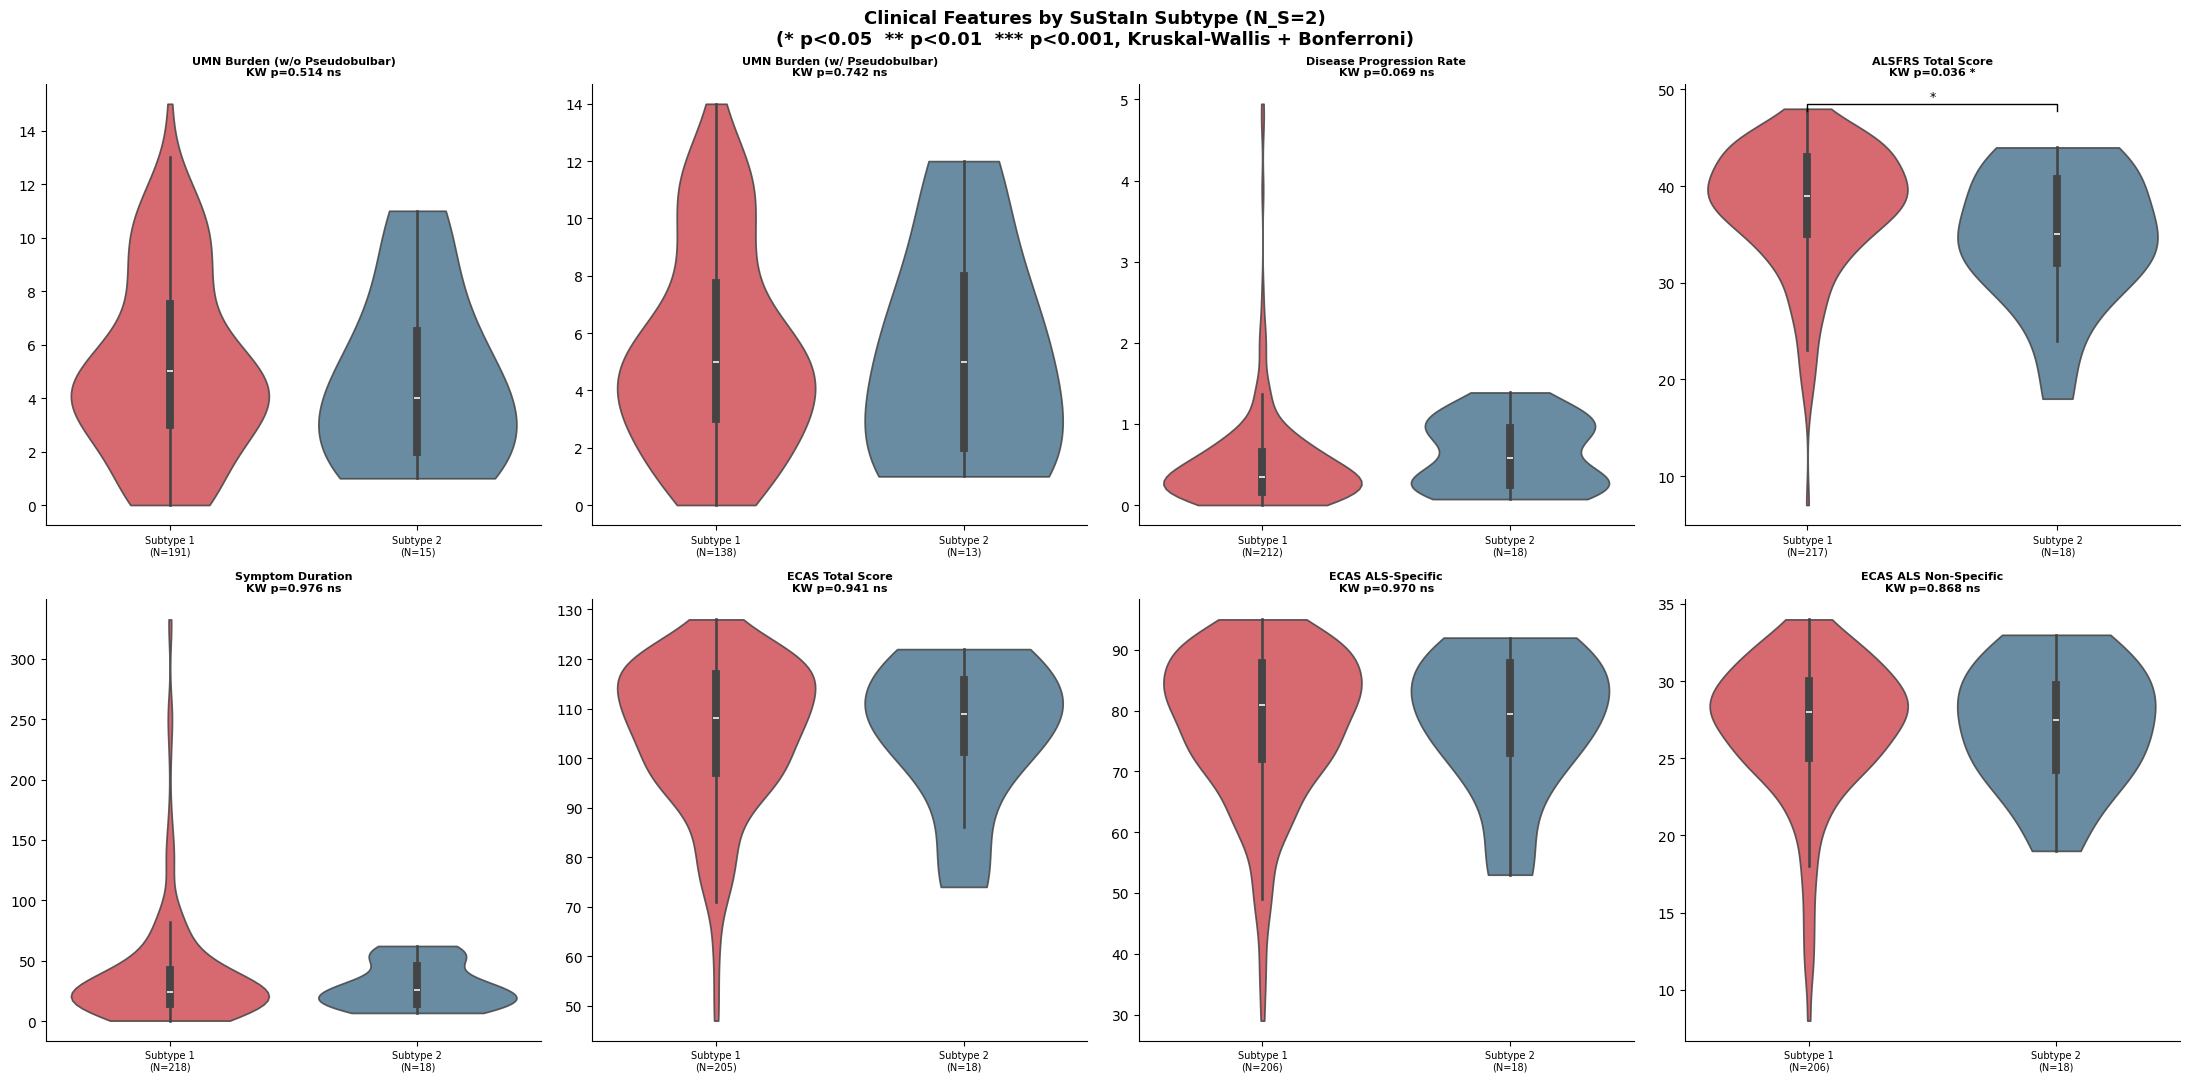


Subtype means per clinical feature:
           UMNBurden_w/o_pseudobulbarscore  UMNBurden_w_PseudobulbarScore  DiseaseProgressionRate  ALSFRS_TotalScore  Symptom_Duration  ECAS_TotalScore  ECAS_ALSSpecific Total  ECAS_ALSNonSpecific Total
Subtype                                                                                                                                                                                                   
Subtype 1                            5.162                          5.355                   0.516             37.899            39.810          105.020                  77.942                     27.010
Subtype 2                            4.600                          5.077                   0.636             34.722            29.756          105.167                  78.056                     27.111


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Clinical measures comparison by SuStaIn subtype
# ══════════════════════════════════════════════════════════════════════════════
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

CLIN_FEATS = [
    'UMNBurden_w/o_pseudobulbarscore','UMNBurden_w_PseudobulbarScore',
    'DiseaseProgressionRate','ALSFRS_TotalScore','Symptom_Duration',
    'ECAS_TotalScore','ECAS_ALSSpecific Total','ECAS_ALSNonSpecific Total',
]
CLIN_LABELS = [
    'UMN Burden (w/o Pseudobulbar)','UMN Burden (w/ Pseudobulbar)',
    'Disease Progression Rate','ALSFRS Total Score','Symptom Duration',
    'ECAS Total Score','ECAS ALS-Specific','ECAS ALS Non-Specific',
]
for c in CLIN_FEATS:
    clin[c] = pd.to_numeric(clin[c], errors='coerce')

clin_v1 = (clin[clin['Patient or Control'] == 'Patient']
           .sort_values('Visit Label').groupby('PSCID', as_index=False).first()
           [['PSCID'] + CLIN_FEATS])

merged_clin = (
    subtype_df.dropna(subset=['PSCID_resolved'])
    .merge(clin_v1, left_on='PSCID_resolved', right_on='PSCID', how='inner')
    .drop(columns=['PSCID_y'], errors='ignore')
    .rename(columns={'PSCID_x':'PSCID'})
)
print(f"Matched for clinical measures: {len(merged_clin)}")
print(merged_clin['Subtype'].value_counts().sort_index())

merged_clin.to_csv(
    '/Users/gracieshao/Desktop/ALS T1s/SuStain/sustain_clinical_merged.csv', index=False)

PALETTE = dict(zip(SUBTYPE_ORDER, ['#E63946','#457B9D','#F4A261'][:N_SUBTYPES]))

def pairwise_mw(data, col, subtypes):
    pairs  = list(combinations(subtypes, 2))
    p_vals = {}
    for s1, s2 in pairs:
        g1 = data.loc[data['Subtype']==s1, col].dropna()
        g2 = data.loc[data['Subtype']==s2, col].dropna()
        if len(g1) < 3 or len(g2) < 3: p_vals[(s1,s2)] = np.nan
        else:
            _, p = mannwhitneyu(g1, g2, alternative='two-sided')
            p_vals[(s1,s2)] = p
    n = sum(1 for v in p_vals.values() if not np.isnan(v))
    return {k: min(v*n, 1.0) for k,v in p_vals.items()}

def sig_label(p):
    if np.isnan(p): return 'n/a'
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    return 'ns'

print(f'\n{"Feature":<40} {"H-stat":>8} {"p-value":>10} {"Sig":>5}')
print('-'*67)
kw_results = {}
for feat, label in zip(CLIN_FEATS, CLIN_LABELS):
    groups = [merged_clin.loc[merged_clin['Subtype']==s, feat].dropna()
              for s in SUBTYPE_ORDER]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) < 2: continue
    h, p = kruskal(*groups)
    kw_results[feat] = {'h':h, 'p':p, 'label':label}
    print(f'{feat[:40]:<40} {h:>8.3f} {p:>10.4f} {sig_label(p):>5}')

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle(f'Clinical Features by SuStaIn Subtype (N_S={N_SUBTYPES})\n'
             '(* p<0.05  ** p<0.01  *** p<0.001, Kruskal-Wallis + Bonferroni)',
             fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes.flat, CLIN_FEATS, CLIN_LABELS):
    plot_data = merged_clin[['Subtype', feat]].dropna()
    sns.violinplot(data=plot_data, x='Subtype', y=feat,
                   order=SUBTYPE_ORDER, palette=PALETTE,
                   ax=ax, inner='box', cut=0, alpha=0.85)
    ns = [merged_clin.loc[merged_clin['Subtype']==s, feat].notna().sum()
          for s in SUBTYPE_ORDER]
    ax.set_xticks(range(N_SUBTYPES))
    ax.set_xticklabels([f'{s}\n(N={n})' for s,n in zip(SUBTYPE_ORDER,ns)], fontsize=7)
    if feat in kw_results:
        p = kw_results[feat]['p']
        ax.set_title(f'{label}\nKW p={p:.3f} {sig_label(p)}', fontsize=8, fontweight='bold')
    else:
        ax.set_title(label, fontsize=8, fontweight='bold')
    if feat in kw_results and kw_results[feat]['p'] < 0.05:
        pw      = pairwise_mw(merged_clin, feat, SUBTYPE_ORDER)
        y_max   = plot_data[feat].quantile(0.95)
        y_range = plot_data[feat].quantile(0.95) - plot_data[feat].quantile(0.05)
        step    = y_range * 0.12
        for idx, ((s1,s2), p_adj) in enumerate(pw.items()):
            if p_adj < 0.05:
                x1, x2 = SUBTYPE_ORDER.index(s1), SUBTYPE_ORDER.index(s2)
                y = y_max + step*(idx+1)
                ax.plot([x1,x1,x2,x2],[y,y+step*0.3,y+step*0.3,y],lw=1,color='black')
                ax.text((x1+x2)/2, y+step*0.35, sig_label(p_adj),
                        ha='center', va='bottom', fontsize=9)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/gracieshao/Desktop/ALS T1s/SuStain/clinical_measures_sustain.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nSubtype means per clinical feature:')
print(merged_clin.groupby('Subtype')[CLIN_FEATS].mean().round(3).to_string())